In [1]:
import geomodel_toolbox
import importlib

importlib.reload(geomodel_toolbox)

Setting Backend To: AvailableBackends.numpy


<module 'geomodel_toolbox' from 'c:\\Users\\ethan\\MSc-Thesis\\GeoModel\\geomodel_toolbox.py'>

In [2]:
import numpy as np
import pandas as pd

In [3]:
#  ====
# Inputs for creating strat model with gempy
#  ====

x_lims = (369702.8, 374398.9)
y_lims = (407778.9, 411690.2)
z_lims = (350, -2000)

resolution = [100, 100, 60]   # nx, ny, nz
 
strat_azimuth = 135 #deg
strat_dip = 10 #deg

#  ====
# Inputs for fracture map
#  ====

aperture = [50, 50] #[m] [MEAN, STD]
radius = [1000, 100] #[m] [MEAN, STD]
azimuth = [45, 10] #[deg] [MEAN, STD]

density = 5e-9 #[fractures/m3]

In [4]:
#geomodel_toolbox.create_strat_model(x_lims, y_lims, z_lims, resolution, strat_azimuth, strat_dip)

c:\Users\ethan\MSc-Thesis\GeoModel\geomodel_toolbox.py:304: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  plotter.show()


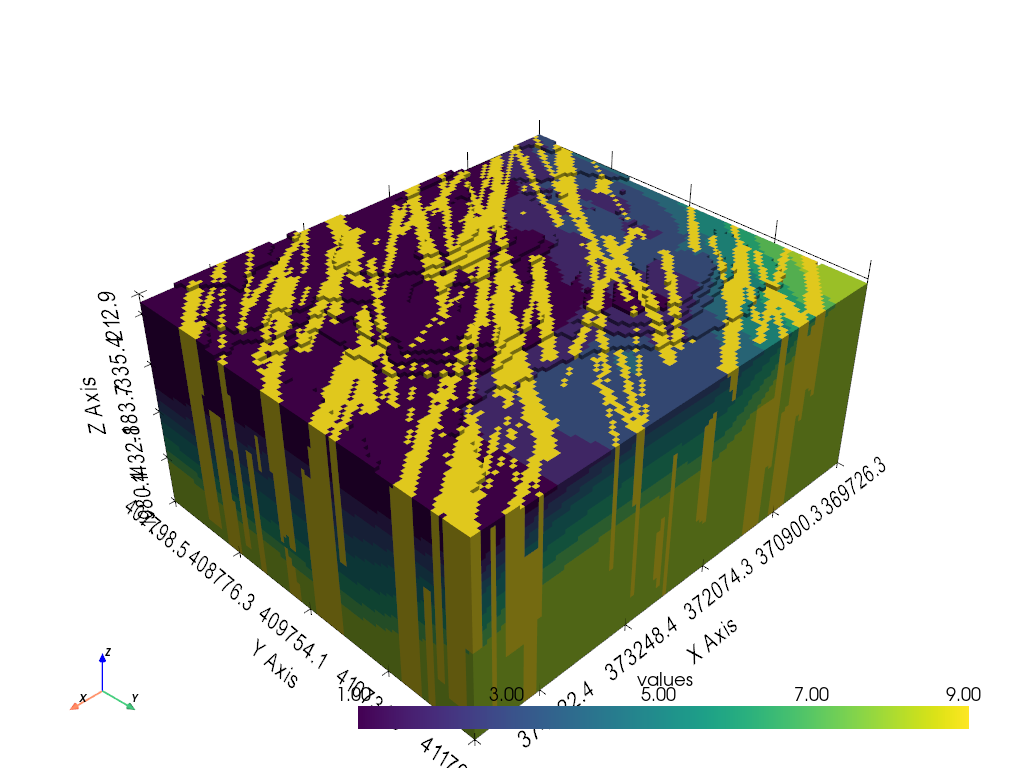

In [5]:
# Import previously defined topo+strat model
lith_topo, x_array, y_array, z_array= geomodel_toolbox.import_strat_model(show_plot=False)

# Generate fracture model based on inputs
mask, df = geomodel_toolbox.generate_fracture_model(x_array, y_array, z_array, aperture, radius, azimuth, density, show_plot=False)

# Combine to get topo+strat+frac model
geomodel = lith_topo.copy()
geomodel[(lith_topo > 0) & mask] = lith_topo.max()+1

# Plot results
geomodel_toolbox.plot_3d_model(geomodel, x_array, y_array, z_array)

In [6]:
import numpy as np

# ============================================================
# INPUTS
# ============================================================

# geomodel : lithology cube
# shape = (NX, NY, NZ)
#
# lithology IDs:
# 0 = air
# 1-9 = rock types

AIR_CODE = 0

#perm in mD
rock_props = {
    1: {"poro": 0.2, "permx": 50}, #top
    2: {"poro": 0.02, "permx": 1e-2}, #B1
    3: {"poro": 0.2, "permx": 50}, #M1
    4: {"poro": 0.02, "permx": 1e-2}, #B2
    5: {"poro": 0.2, "permx": 50}, #M2
    6: {"poro": 0.02, "permx": 1e-2}, #B3
    7: {"poro": 0.2, "permx": 50}, #M3
    8: {"poro": 0.02, "permx": 1e-2}, #B4
    9: {"poro": 0.1, "permx": 1e3}, #faults -- good o.o.m. but check porosity
}

output_file = "reservoir.grdecl"

# ============================================================
# HELPERS
# ============================================================

def centers_to_edges(c):
    c = np.asarray(c)

    edges = np.empty(len(c) + 1)

    edges[1:-1] = (c[:-1] + c[1:]) / 2

    edges[0] = c[0] - (c[1] - c[0]) / 2
    edges[-1] = c[-1] + (c[-1] - c[-2]) / 2

    return edges


def write_keyword_array(f, keyword, arr):

    f.write(f"{keyword}\n")

    values = np.asarray(arr).flatten(order="F")

    for i, v in enumerate(values):

        if np.issubdtype(type(v), np.integer):
            f.write(f"{int(v)} ")
        else:
            f.write(f"{float(v):.6g} ")

        if (i + 1) % 8 == 0:
            f.write("\n")

    f.write("\n/\n\n")


# ============================================================
# GRID
# ============================================================

lith = geomodel.astype(int)

NX, NY, NZ = lith.shape

x_edges = centers_to_edges(x_array)
y_edges = centers_to_edges(y_array)
z_edges = centers_to_edges(z_array)

# ============================================================
# ACTNUM
# ============================================================

# Air cells inactive
actnum = (lith != AIR_CODE).astype(int)

# ============================================================
# ROCK PROPERTIES
# ============================================================

poro = np.zeros_like(lith, dtype=float)
permx = np.zeros_like(lith, dtype=float)

for facies, props in rock_props.items():

    mask = lith == facies

    poro[mask] = props["poro"]
    permx[mask] = props["permx"]

# ============================================================
# WRITE GRDECL
# ============================================================

with open(output_file, "w") as f:

    # --------------------------------------------------------
    # SPECGRID
    # --------------------------------------------------------

    f.write("SPECGRID\n")
    f.write(f"{NX} {NY} {NZ} 1 F /\n\n")

    # --------------------------------------------------------
    # COORD
    # --------------------------------------------------------

    f.write("COORD\n")

    z_top = z_edges[0]
    z_bottom = z_edges[-1]

    for y in y_edges:
        for x in x_edges:

            f.write(
                f"{x:.6f} {y:.6f} {z_top:.6f} "
                f"{x:.6f} {y:.6f} {z_bottom:.6f}\n"
            )

    f.write("/\n\n")

    # --------------------------------------------------------
    # ZCORN
    # --------------------------------------------------------

    f.write("ZCORN\n")

    counter = 0

    for k in range(NZ):

        top = z_edges[k]
        bottom = z_edges[k + 1]

        for _ in range(NX * NY):

            vals = [
                top, top, top, top,
                bottom, bottom, bottom, bottom
            ]

            for v in vals:

                f.write(f"{v:.6f} ")

                counter += 1

                if counter % 8 == 0:
                    f.write("\n")

    f.write("/\n\n")

    # --------------------------------------------------------
    # ACTNUM
    # --------------------------------------------------------

    write_keyword_array(f, "ACTNUM", actnum)

    # --------------------------------------------------------
    # FACIES
    # --------------------------------------------------------

    write_keyword_array(f, "FACIES", lith)

    # --------------------------------------------------------
    # PORO
    # --------------------------------------------------------

    write_keyword_array(f, "PORO", poro)

    # --------------------------------------------------------
    # PERMX
    # --------------------------------------------------------

    write_keyword_array(f, "PERMX", permx)

print(f"Written: {output_file}")
print(f"Grid dimensions: {NX} x {NY} x {NZ}")
print(f"Total cells: {NX*NY*NZ:,}")
print(f"Active cells: {actnum.sum():,}")
print(f"Inactive air cells: {(actnum == 0).sum():,}")

Written: reservoir.grdecl
Grid dimensions: 100 x 100 x 60
Total cells: 600,000
Active cells: 518,499
Inactive air cells: 81,501


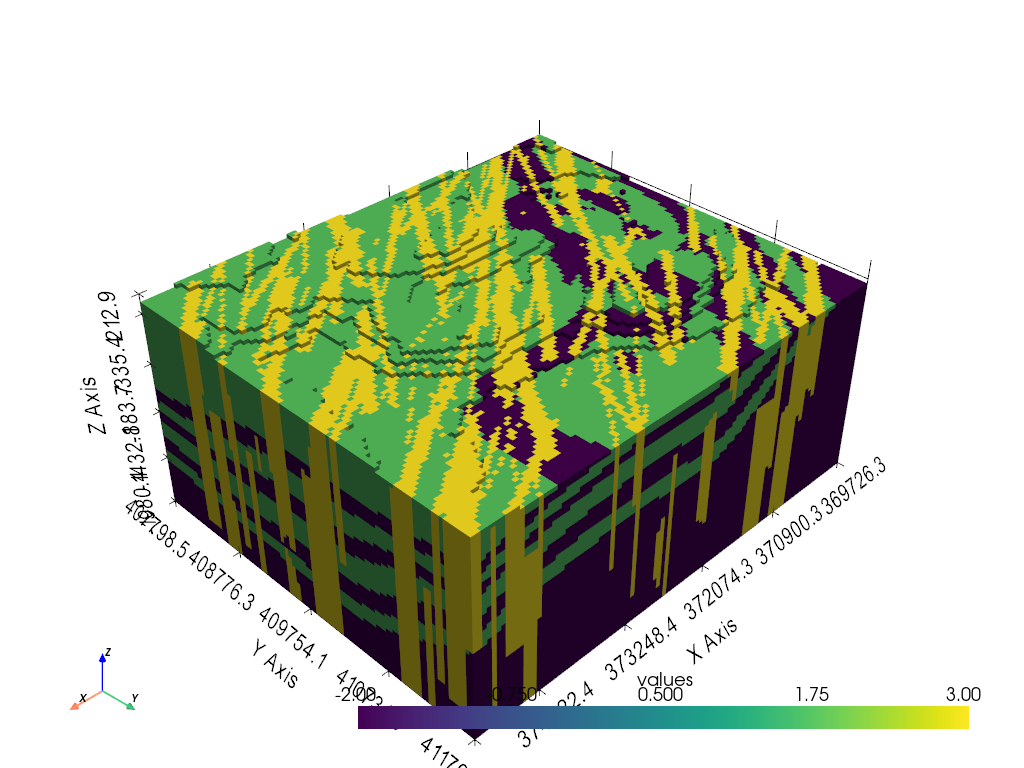

In [7]:
geomodel_toolbox.plot_3d_model(permx, x_array, y_array, z_array, scale='log')

In [8]:
well_data = pd.read_csv('gempy_inputs/borehole_data.csv')

well_data

,name,x,y,depth,casing
0,MG-01,370202.8,409173.7,1377.0,99.0
1,MG-03,370455.1,408920.9,1414.0,117.8
2,MG-04,370758.0,408722.9,1334.9,570.0
3,MG-05,372729.4,410731.7,1592.0,133.2
4,MG-06,370502.0,408796.2,1416.0,9.0
5,MG-07,370523.3,408319.9,1484.0,132.3
6,MG-08,370374.3,408714.5,1564.0,133.2
7,MG-09,370213.9,408870.8,1803.0,155.4
8,MG-10,370779.5,408388.4,1045.0,1021.6
9,MG-11,371013.9,408855.0,1235.0,167.0


In [9]:
x_array

array([369726.2805, 369773.2415, 369820.2025, 369867.1635, 369914.1245,
       369961.0855, 370008.0465, 370055.0075, 370101.9685, 370148.9295,
       370195.8905, 370242.8515, 370289.8125, 370336.7735, 370383.7345,
       370430.6955, 370477.6565, 370524.6175, 370571.5785, 370618.5395,
       370665.5005, 370712.4615, 370759.4225, 370806.3835, 370853.3445,
       370900.3055, 370947.2665, 370994.2275, 371041.1885, 371088.1495,
       371135.1105, 371182.0715, 371229.0325, 371275.9935, 371322.9545,
       371369.9155, 371416.8765, 371463.8375, 371510.7985, 371557.7595,
       371604.7205, 371651.6815, 371698.6425, 371745.6035, 371792.5645,
       371839.5255, 371886.4865, 371933.4475, 371980.4085, 372027.3695,
       372074.3305, 372121.2915, 372168.2525, 372215.2135, 372262.1745,
       372309.1355, 372356.0965, 372403.0575, 372450.0185, 372496.9795,
       372543.9405, 372590.9015, 372637.8625, 372684.8235, 372731.7845,
       372778.7455, 372825.7065, 372872.6675, 372919.6285, 37296

In [10]:
z_array

array([-1980.41666667, -1941.25      , -1902.08333333, -1862.91666667,
       -1823.75      , -1784.58333333, -1745.41666667, -1706.25      ,
       -1667.08333333, -1627.91666667, -1588.75      , -1549.58333333,
       -1510.41666667, -1471.25      , -1432.08333333, -1392.91666667,
       -1353.75      , -1314.58333333, -1275.41666667, -1236.25      ,
       -1197.08333333, -1157.91666667, -1118.75      , -1079.58333333,
       -1040.41666667, -1001.25      ,  -962.08333333,  -922.91666667,
        -883.75      ,  -844.58333333,  -805.41666667,  -766.25      ,
        -727.08333333,  -687.91666667,  -648.75      ,  -609.58333333,
        -570.41666667,  -531.25      ,  -492.08333333,  -452.91666667,
        -413.75      ,  -374.58333333,  -335.41666667,  -296.25      ,
        -257.08333333,  -217.91666667,  -178.75      ,  -139.58333333,
        -100.41666667,   -61.25      ,   -22.08333333,    17.08333333,
          56.25      ,    95.41666667,   134.58333333,   173.75      ,
      

In [11]:
import numpy as np


def nearest_eclipse_index(value, axis):
    return np.argmin(np.abs(axis - value)) + 1


def wells_to_compdat(wells, x_array, y_array, z_array, outfile="well_data.inc"):

    lines = ["--perforations in Eclipse format I, J, K1-K2, 1-based indices",
             "COMPDAT"]

    for _, row in wells.iterrows():

        I = nearest_eclipse_index(row.x, x_array)
        J = nearest_eclipse_index(row.y, y_array)

        z_casing = -row.casing
        z_depth = -row.depth

        K1 = nearest_eclipse_index(z_casing, z_array)
        K2 = nearest_eclipse_index(z_depth, z_array)

        K1, K2 = sorted((K1, K2))

        lines.append(f"PRD {I} {J} {K1} {K2} /")

    text = "\n".join(lines)

    with open(outfile, "w") as f:
        f.write(text)

    return text

wells_to_compdat(
    well_data,
    x_array,
    y_array,
    z_array
)

'--perforations in Eclipse format I, J, K1-K2, 1-based indices\nCOMPDAT\nPRD 11 36 16 49 /\nPRD 17 30 15 49 /\nPRD 23 25 17 37 /\nPRD 65 76 11 48 /\nPRD 18 27 15 51 /\nPRD 18 14 14 48 /\nPRD 15 24 12 48 /\nPRD 11 28 6 48 /\nPRD 23 16 25 25 /\nPRD 28 28 20 47 /\nPRD 24 35 31 47 /\nPRD 20 44 3 47 /\nPRD 16 31 1 46 /\nPRD 18 33 1 46 /\nPRD 22 50 1 46 /\nPRD 23 16 6 36 /\nPRD 17 28 1 47 /\nPRD 50 81 13 47 /\nPRD 21 40 1 47 /\nPRD 70 71 6 48 /\nPRD 30 22 14 47 /\nPRD 26 13 21 36 /\nPRD 29 27 2 47 /\nPRD 18 51 1 46 /\nPRD 29 18 29 46 /\nPRD 30 20 1 47 /\nPRD 59 79 1 47 /\nPRD 30 25 11 47 /\nPRD 28 17 14 47 /\nPRD 81 64 18 45 /\nPRD 86 51 5 45 /\nPRD 86 60 3 45 /\nPRD 86 36 3 45 /\nPRD 86 65 3 51 /\nPRD 41 88 1 45 /\nPRD 86 56 6 45 /\nPRD 90 35 1 42 /\nPRD 15 32 1 36 /'